In [1]:
import joblib
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import export_graphviz
import graphviz

In [2]:
modelo = joblib.load('../../assets/resultados_modelos/experimento_1_v2/random_forest_sin_boostrap_1.pkl')

In [4]:
x_train = pd.read_csv('../../assets/gold/experimentos_finales/x_train.csv')
feature_names= x_train.columns.tolist()

In [5]:
modelo

RandomForestClassifier(bootstrap=False, max_depth=3, n_estimators=10,
                       random_state=42)

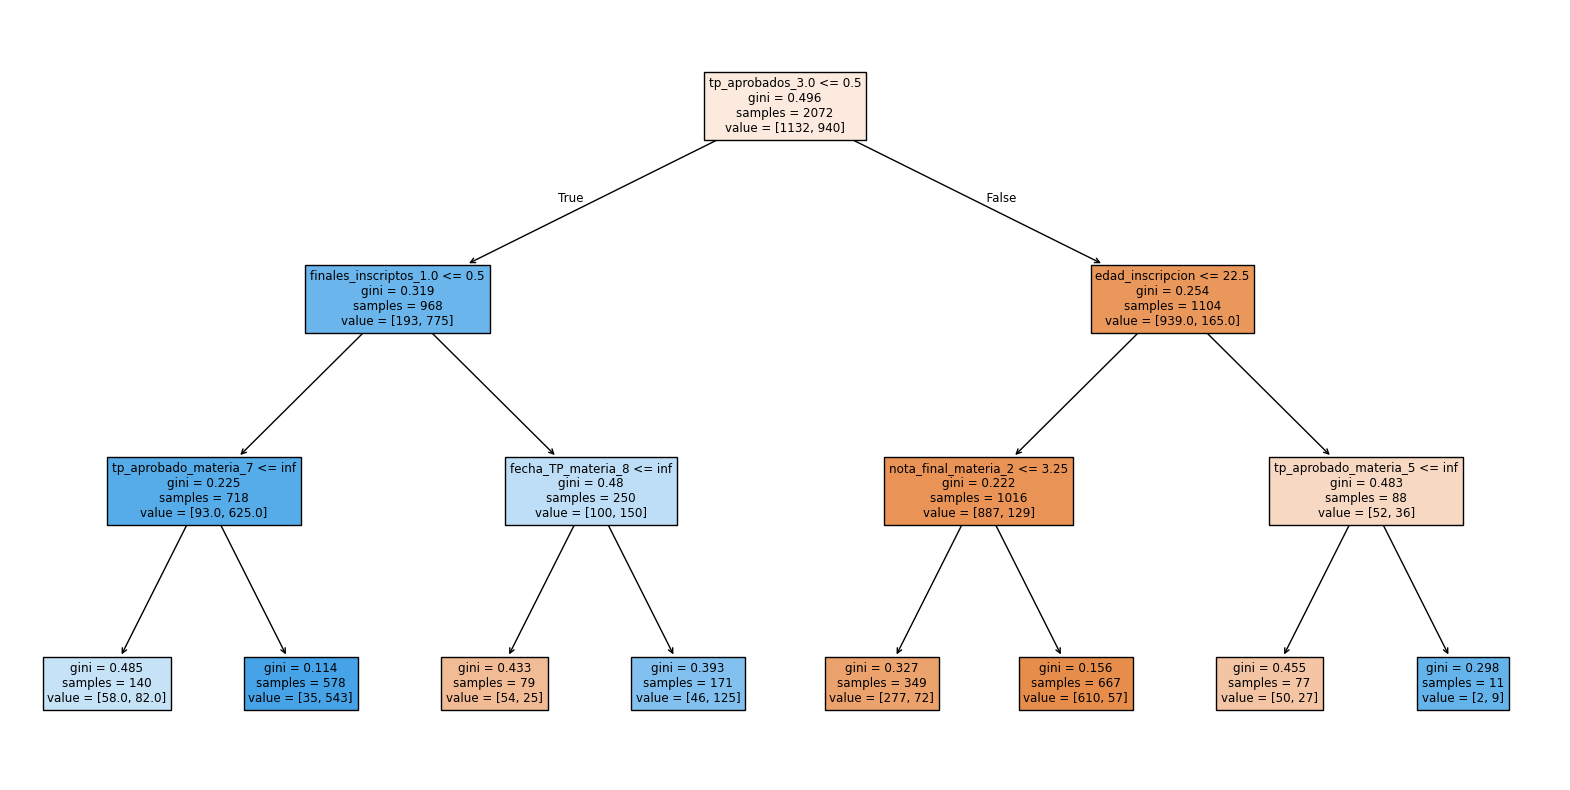

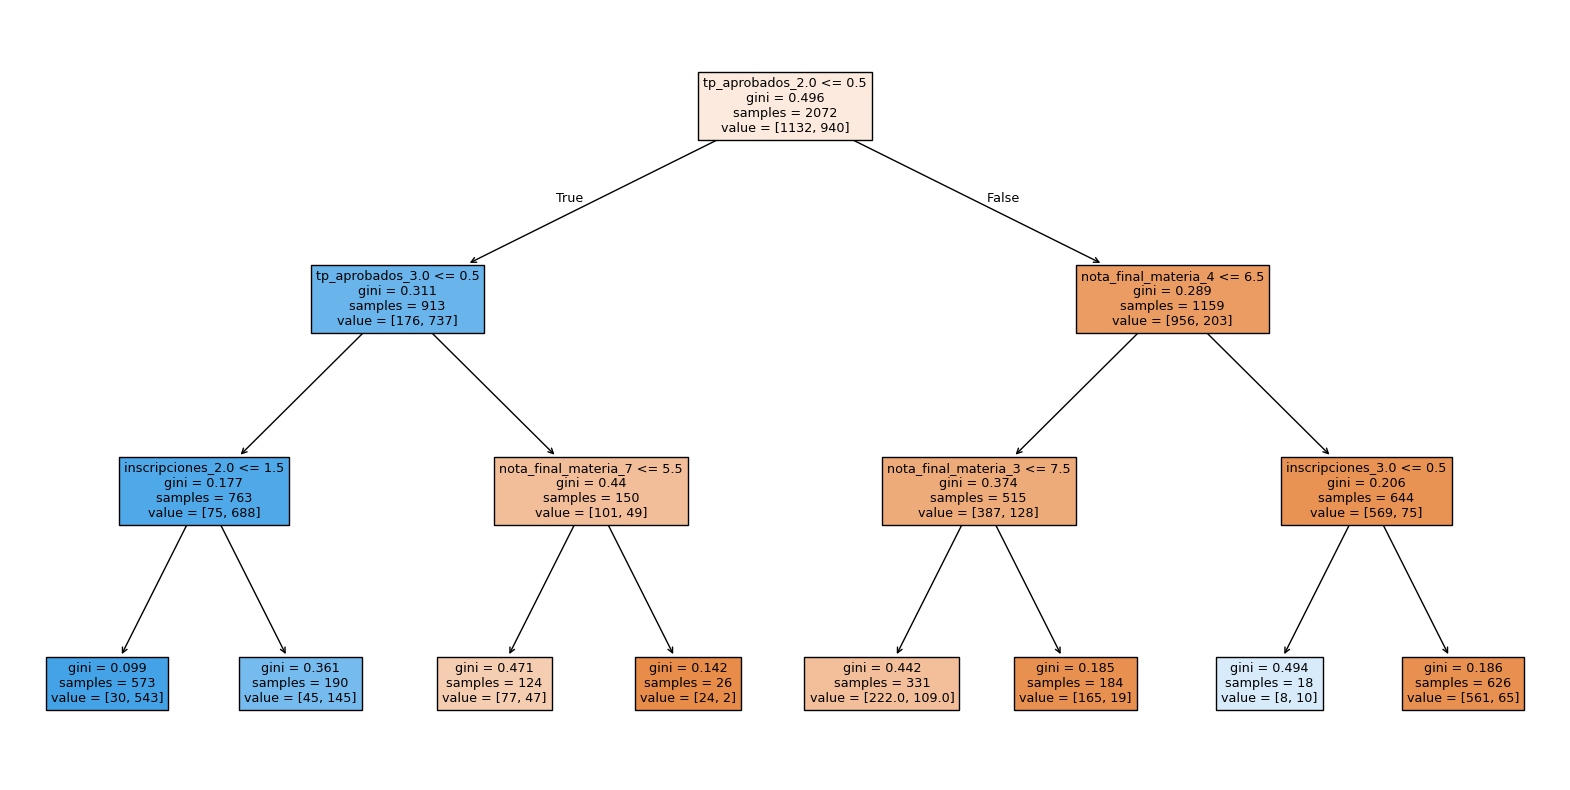

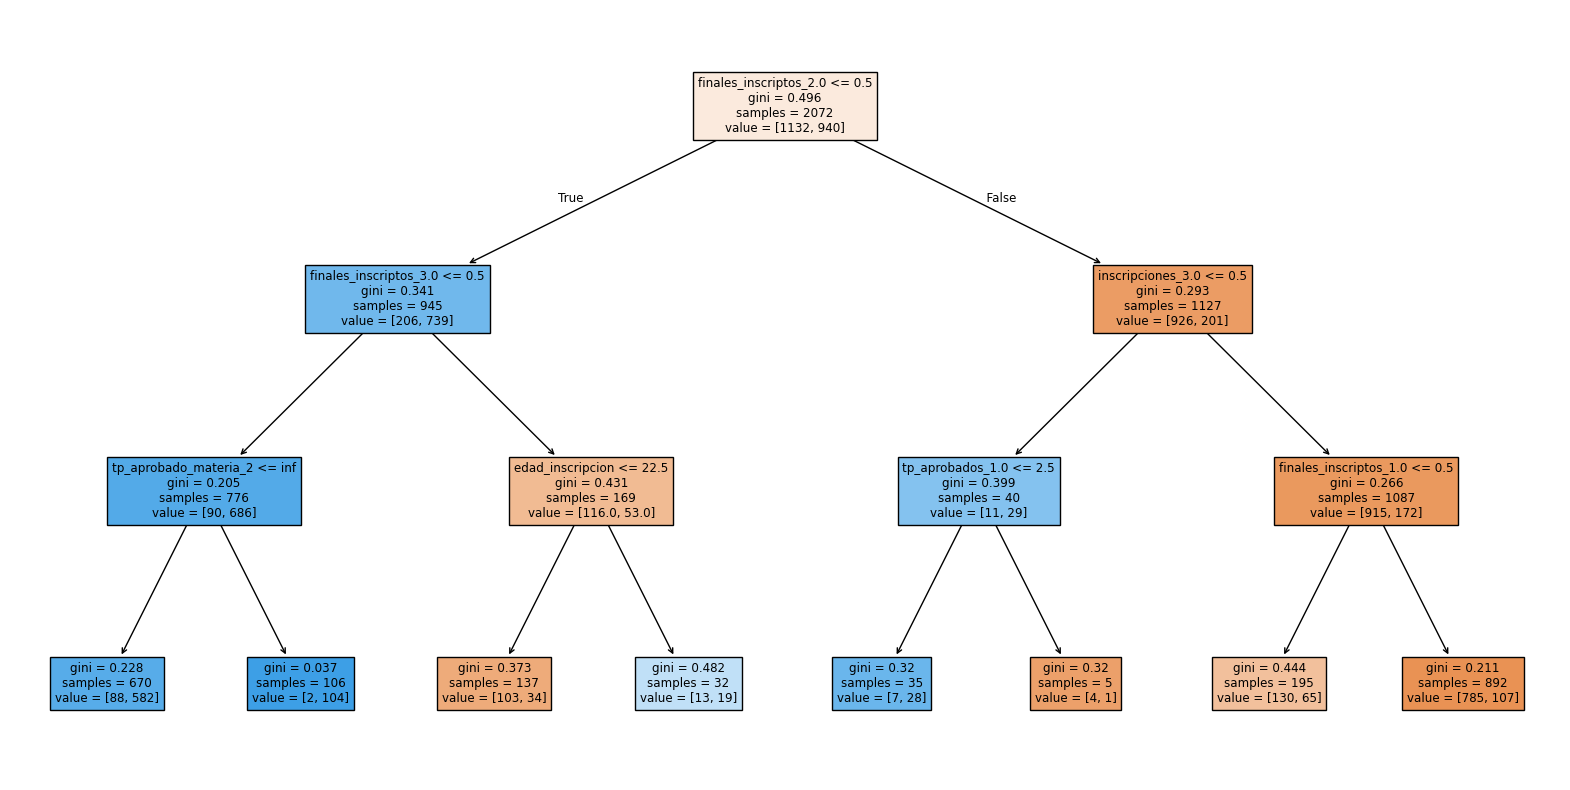

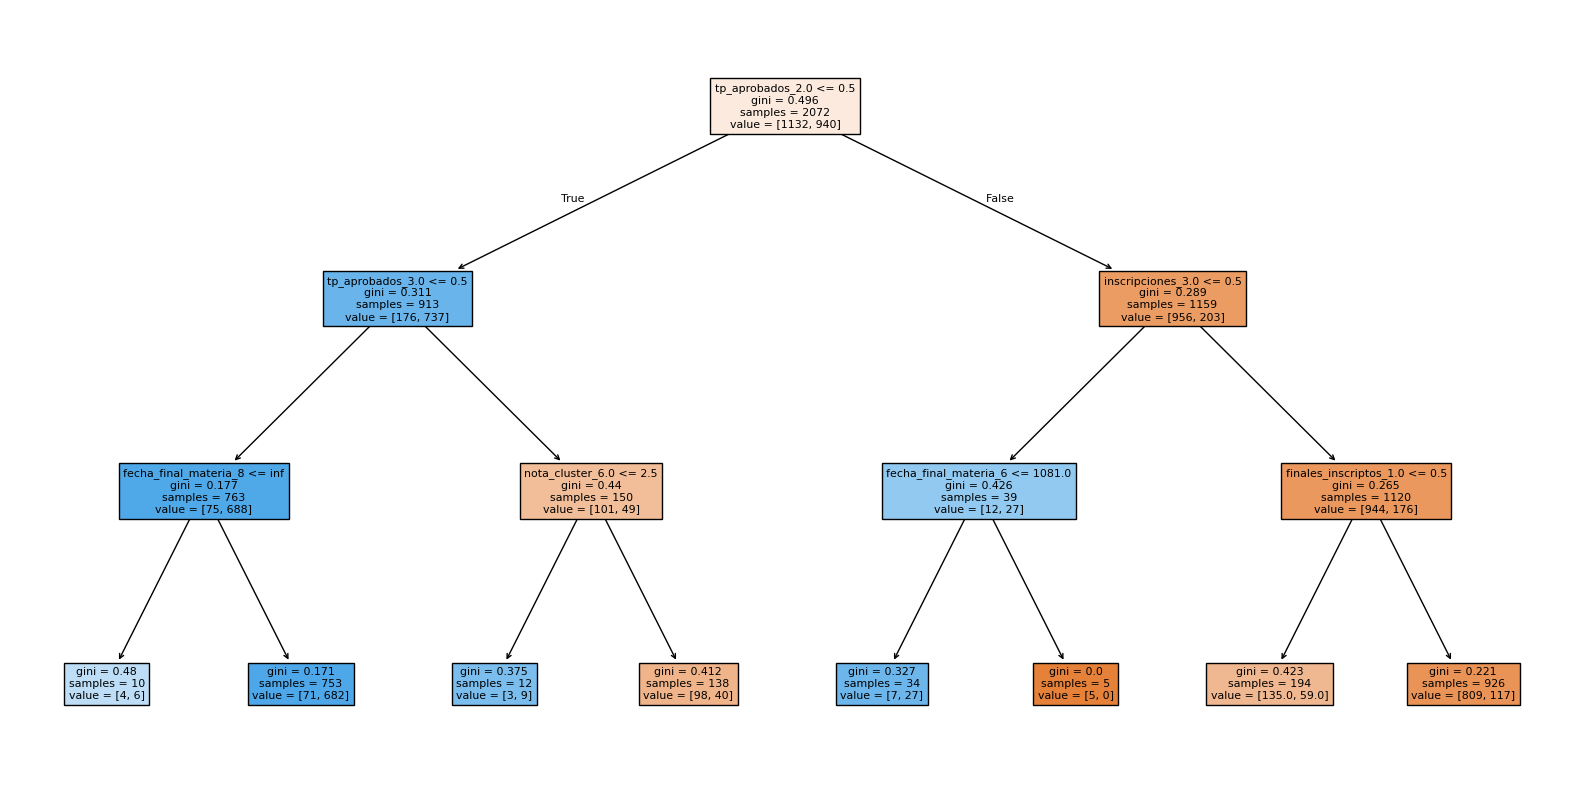

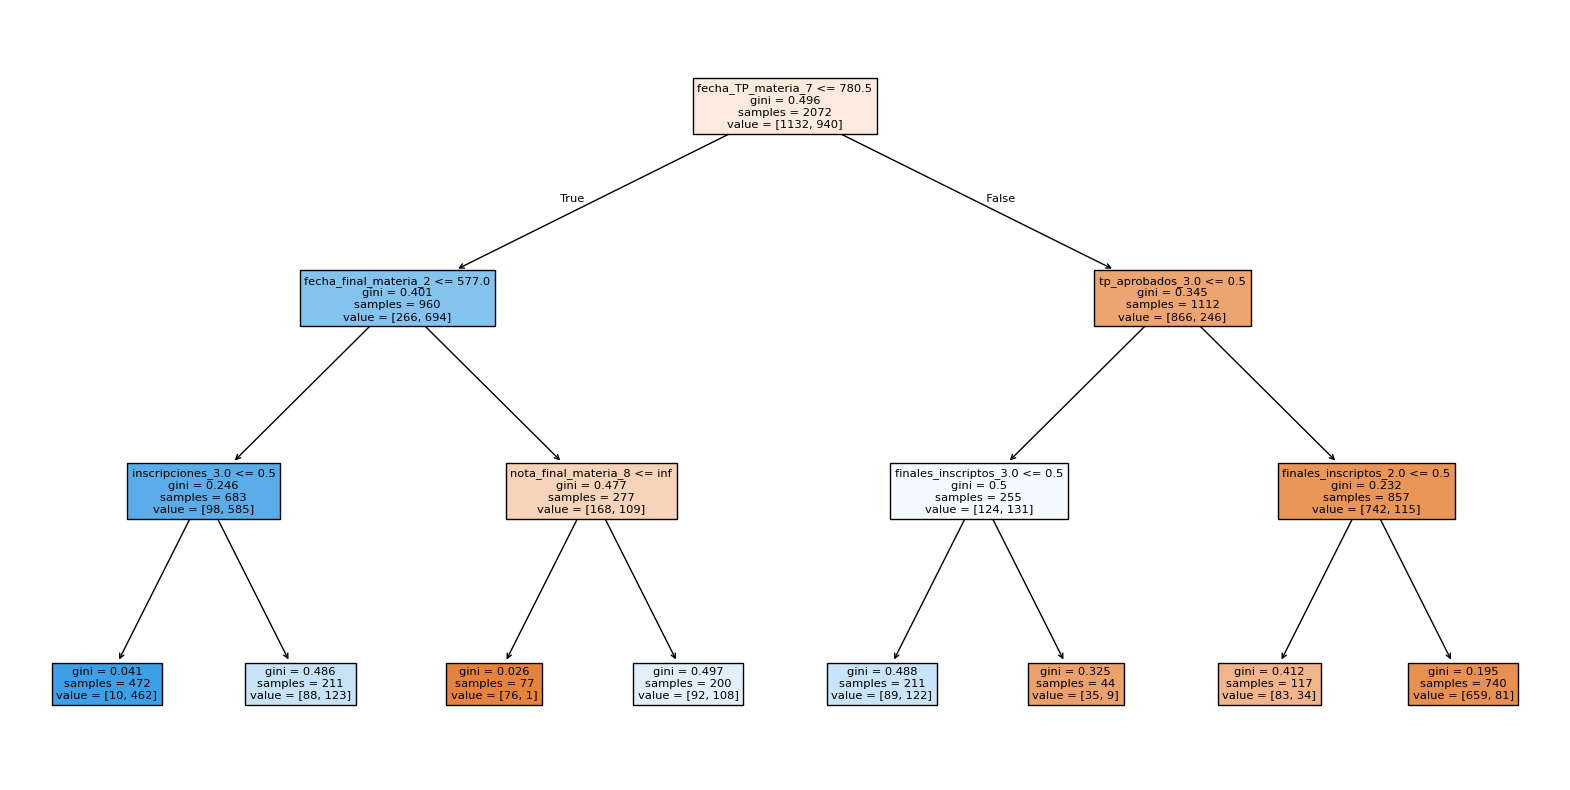

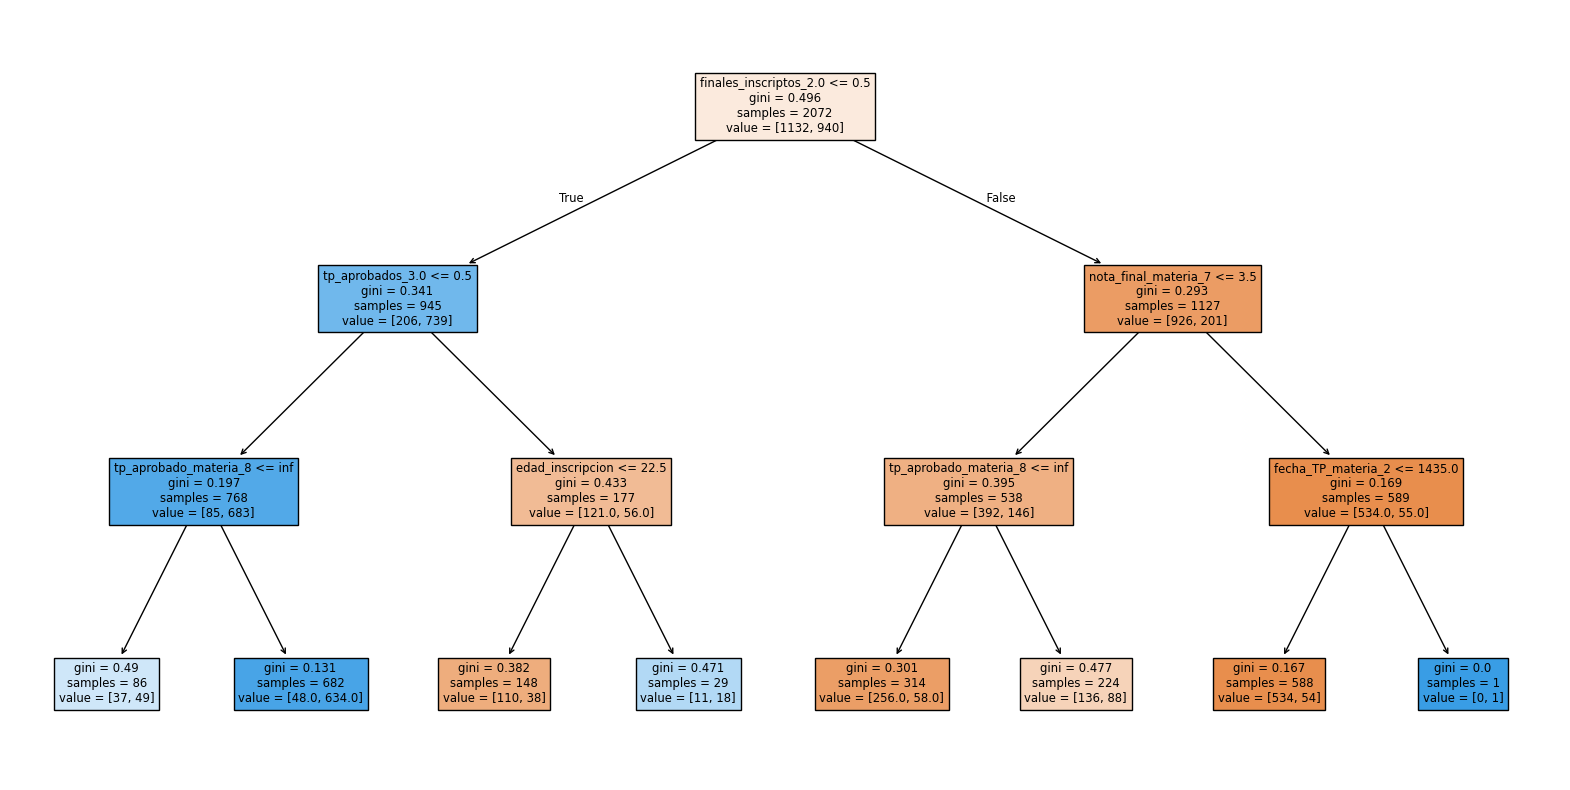

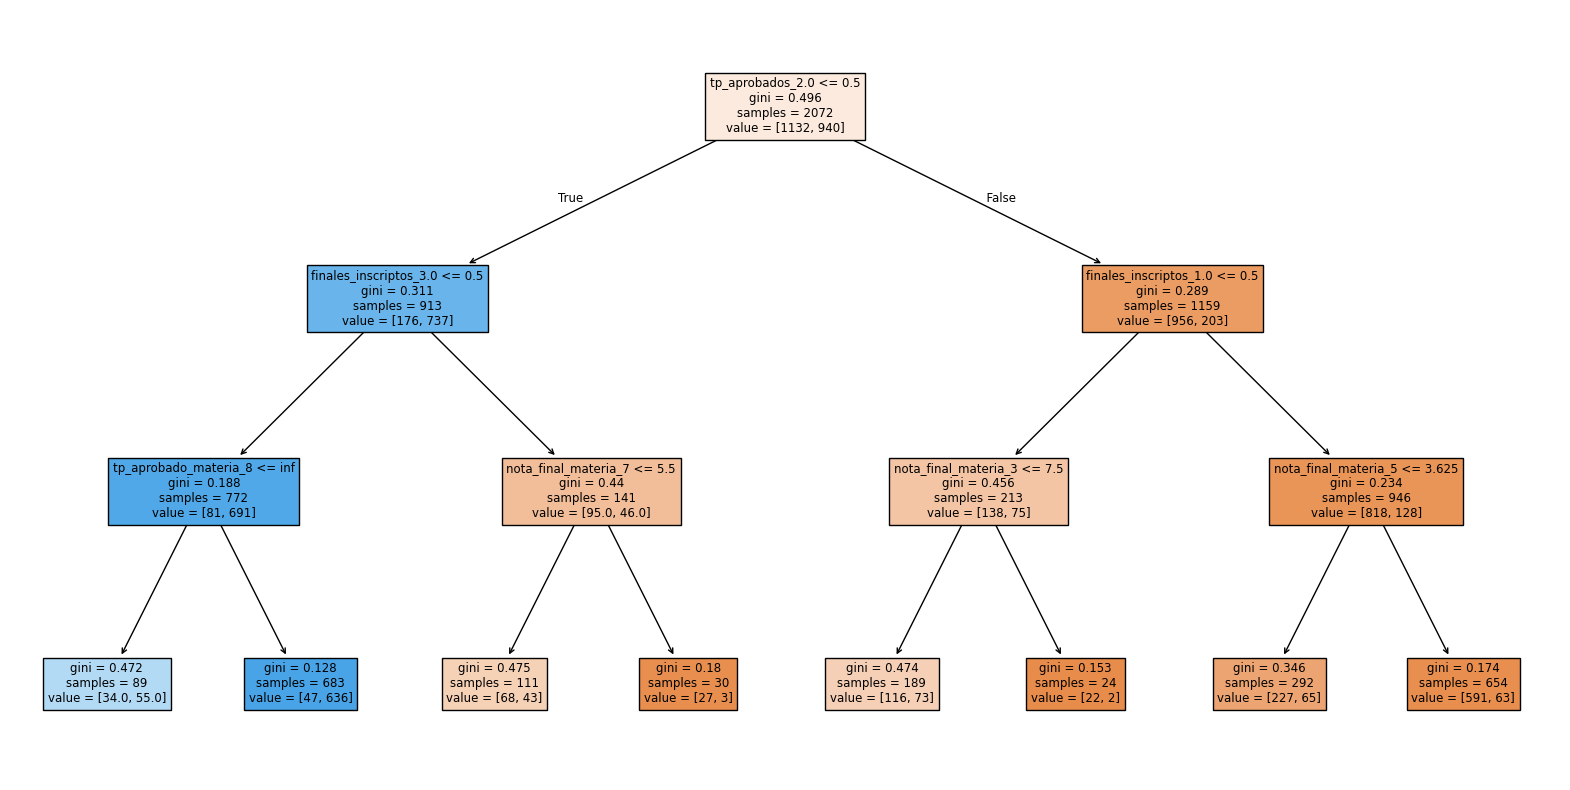

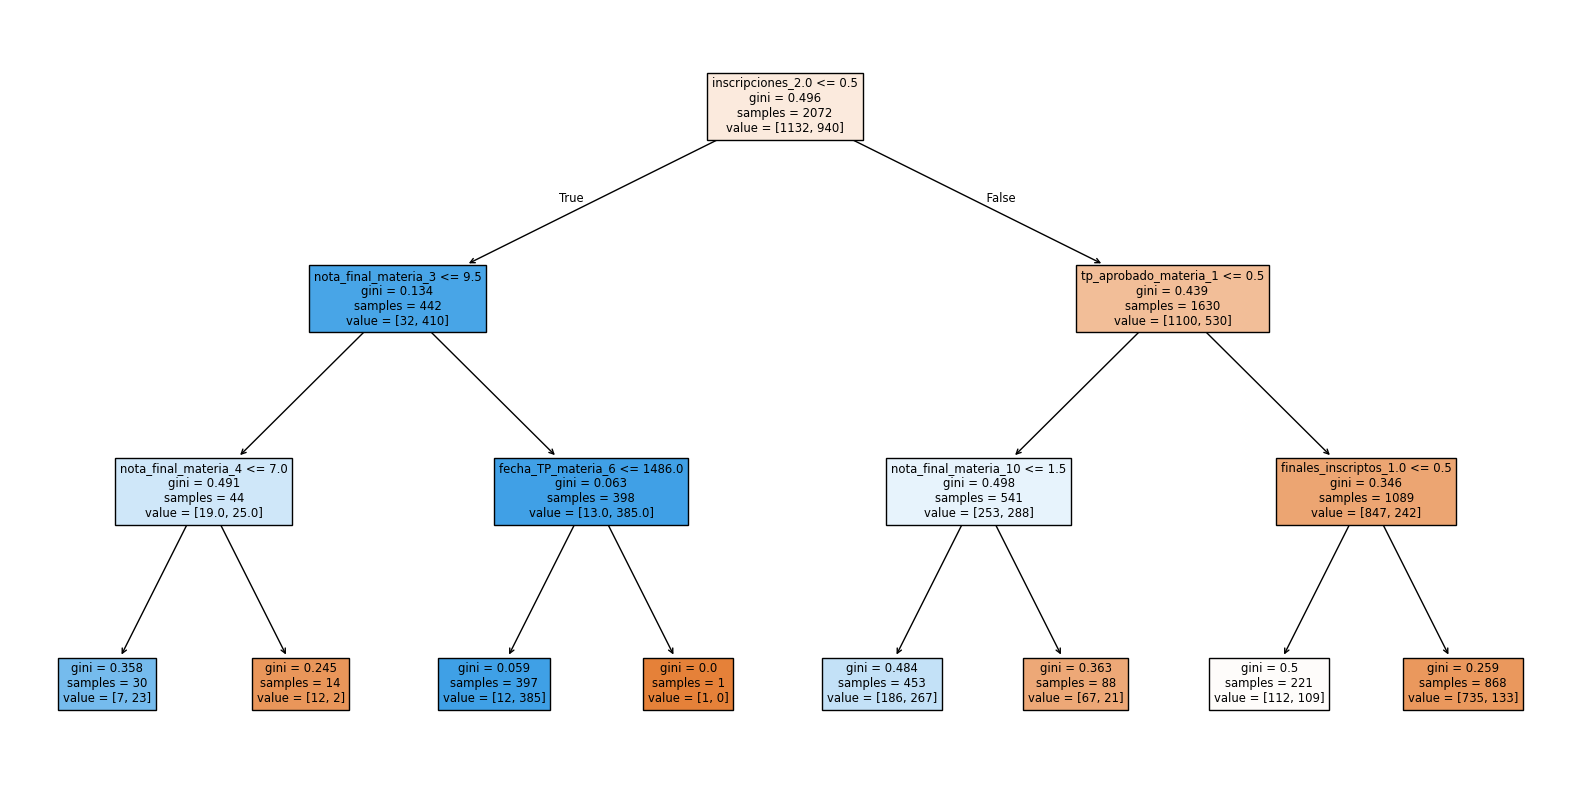

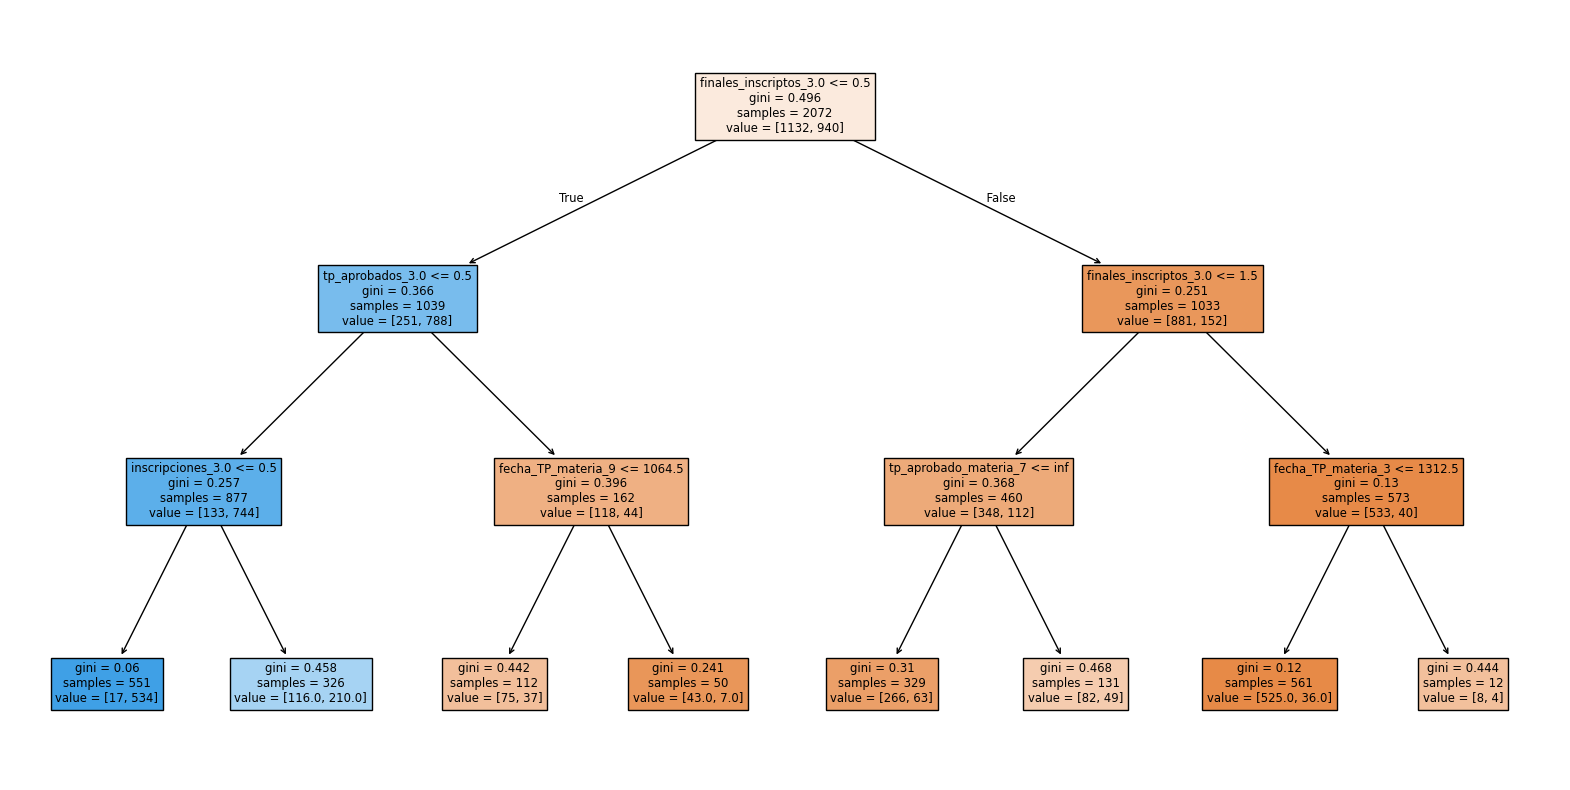

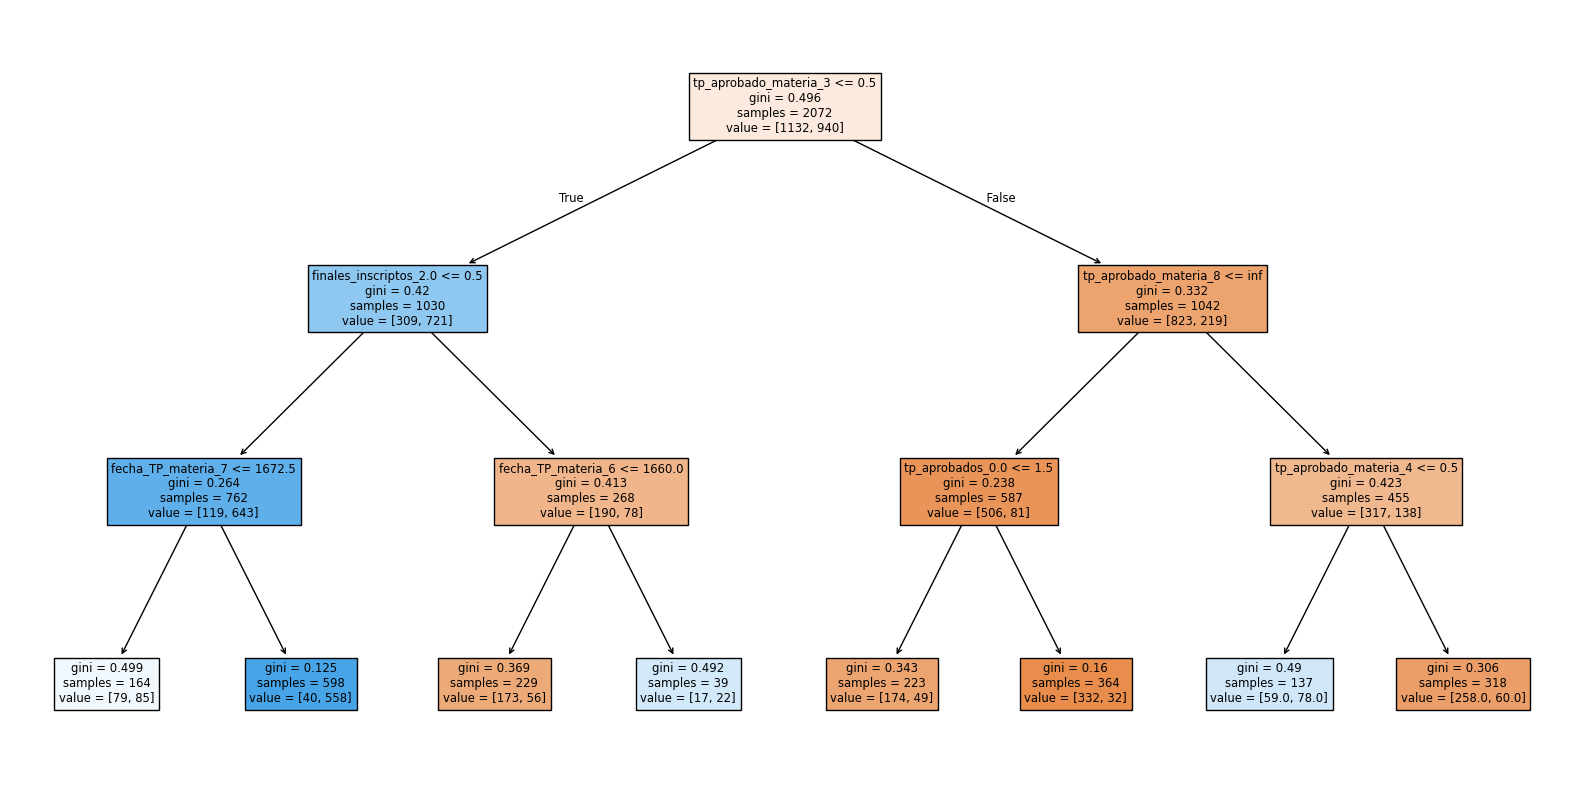

In [8]:
for i in range(10):
    plt.figure(figsize=(20, 10))
    plot_tree(modelo.estimators_[i], filled=True, max_depth=3, feature_names=feature_names)
    plt.show()

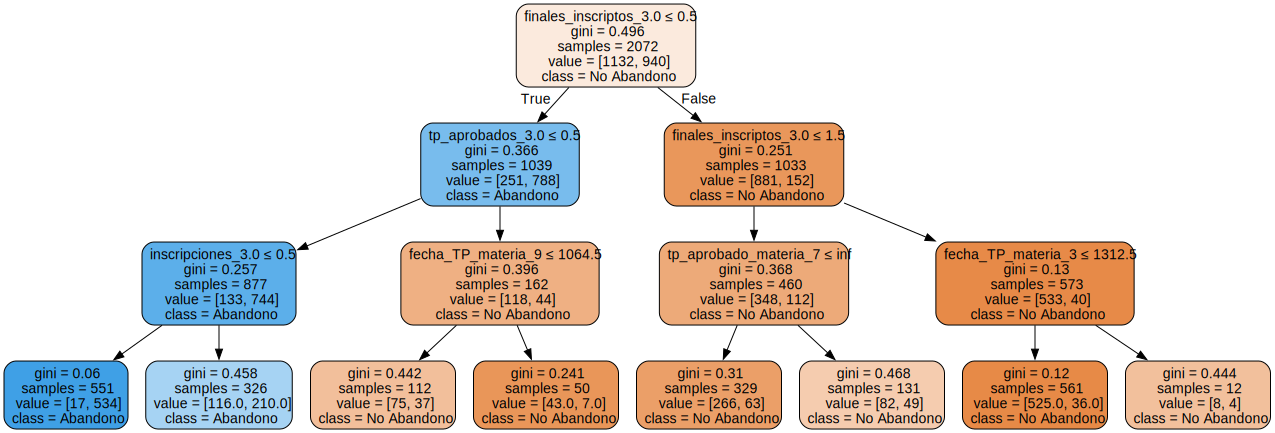

In [9]:
# Exportar el árbol como texto DOT
dot_data = export_graphviz(
    modelo.estimators_[8],             # el árbol individual
    out_file=None,                     # lo devolvemos como string, no guardamos aún
    feature_names=feature_names,       # nombres de variables
    class_names=['No Abandono', 'Abandono'],# opcional: nombres de clases
    filled=True, rounded=True,         # colores y bordes redondeados
    special_characters=True
)

# Renderizar con graphviz
graph = graphviz.Source(dot_data)
#graph.render("arbol_random_forest", format="png", cleanup=True)  # guarda el PNG
graph                         # esto lo muestra en Jupyter/lab si estás ahí

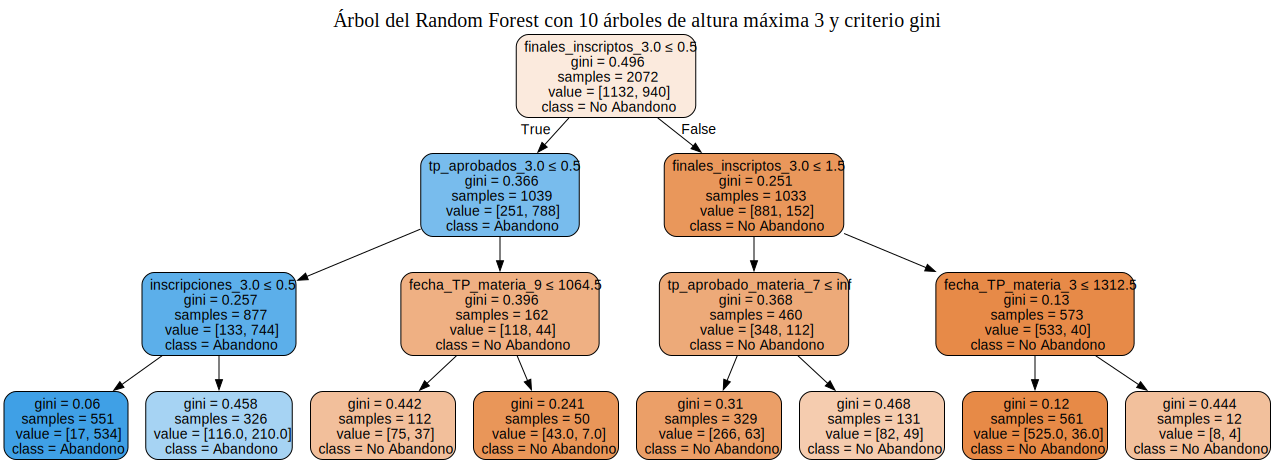

In [10]:
# Agregar un título al grafo DOT
dot_data = dot_data.replace('digraph Tree {', 'digraph Tree {\nlabel="Árbol del Random Forest con 10 árboles de altura máxima 3 y criterio gini";\nlabelloc=top;\nfontsize=20;')
graph = graphviz.Source(dot_data)
graph

In [11]:
graph.render("arbol_random_forest", format="svg", cleanup=True)

'arbol_random_forest.svg'